<a href="https://colab.research.google.com/github/itzyishu/qskill/blob/main/Qskill.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas numpy matplotlib scikit-learn

In [ ]:

import numpy as np
import pandas as pd

np.random.seed(42)
n = 500

locations = ["Downtown", "Suburb", "Rural", "Beachfront", "City Center"]
location_price_multiplier = {
    "Downtown": 1.4, "Suburb": 1.0, "Rural": 0.7,
    "Beachfront": 1.8, "City Center": 1.5,
}

size_sqft = np.random.normal(1800, 600, n).clip(400, 5000)
rooms = np.clip((size_sqft / 450 + np.random.normal(0, 0.5, n)).round(), 1, 8).astype(int)
bathrooms = np.clip((rooms / 2 + np.random.normal(0, 0.4, n)).round(), 1, 5).astype(int)
age_years = np.random.randint(0, 50, n)
location = np.random.choice(locations, n)
distance_to_city_km = np.round(np.random.uniform(0.5, 30, n), 1)

base_price = (
    size_sqft * 150
    + rooms * 8000
    + bathrooms * 5000
    - age_years * 600
    - distance_to_city_km * 1200
)

price = base_price * np.array([location_price_multiplier[loc] for loc in location])
price += np.random.normal(0, 15000, n)   # random noise
price = price.clip(50000, None).round(2)

df = pd.DataFrame({
    "Size_sqft": size_sqft.round(1),
    "Rooms": rooms,
    "Bathrooms": bathrooms,
    "Age_years": age_years,
    "Location": location,
    "Distance_to_City_km": distance_to_city_km,
    "Price": price,
})

df.to_csv("housing_data.csv", index=False)
print("Sample dataset created: housing_data.csv")
print(df.head())
print(f"\nShape: {df.shape}")

Sample dataset created: housing_data.csv
   Size_sqft  Rooms  Bathrooms  Age_years     Location  Distance_to_City_km  \
0     2098.0      5          3         30   Beachfront                 25.8   
1     1717.0      5          3         18     Downtown                  6.0   
2     2188.6      4          2         48  City Center                 16.8   
3     2713.8      6          3         45        Rural                 12.8   
4     1659.5      3          2         18   Beachfront                 21.7   

       Price  
0  626247.06  
1  411585.26  
2  487740.89  
3  292207.51  
4  442995.43  

Shape: (500, 7)


Loaded dataset: 500 rows, 7 columns
   Size_sqft  Rooms  Bathrooms  Age_years     Location  Distance_to_City_km  \
0     2098.0      5          3         30   Beachfront                 25.8   
1     1717.0      5          3         18     Downtown                  6.0   
2     2188.6      4          2         48  City Center                 16.8   
3     2713.8      6          3         45        Rural                 12.8   
4     1659.5      3          2         18   Beachfront                 21.7   

       Price  
0  626247.06  
1  411585.26  
2  487740.89  
3  292207.51  
4  442995.43  

--- Model Evaluation ---
Mean Absolute Error (MAE): 29,932.12
Root Mean Squared Error (RMSE): 41,269.60
R-squared (R²): 0.9415  (94.1% of price variance explained)

--- Feature Influence on Price (standardized coefficients) ---
Location_Rural         -313005.721592
Location_Suburb        -228683.911857
Location_Downtown      -115524.071793
Size_sqft               110012.806509
Location_City Cent

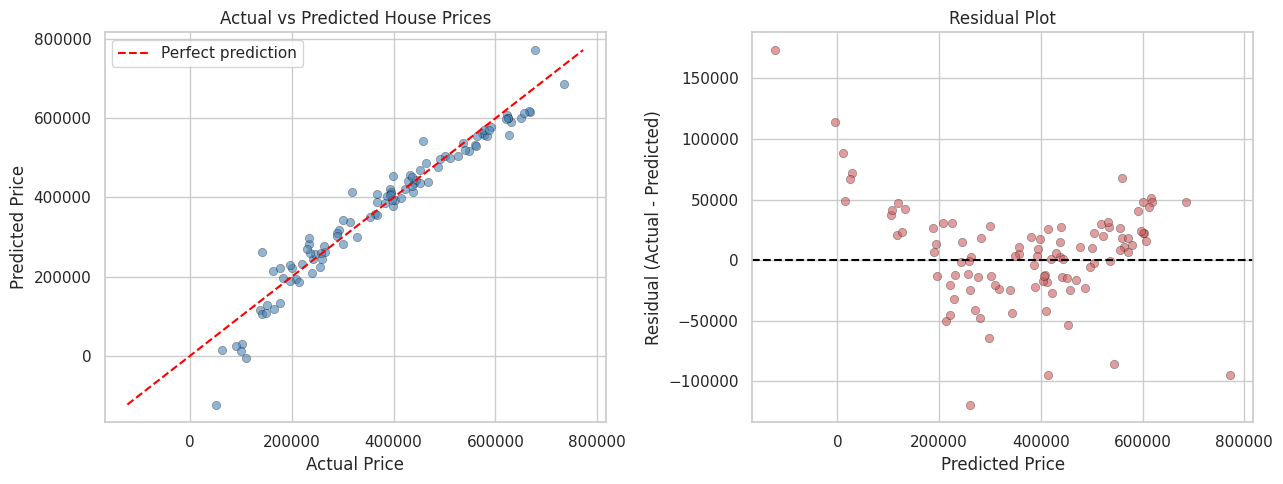

In [ ]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

CSV_PATH = "housing_data.csv"
TARGET_COLUMN = "Price"
CATEGORICAL_COLUMNS = ["Location"]
NUMERIC_COLUMNS = ["Size_sqft", "Rooms", "Bathrooms", "Age_years", "Distance_to_City_km"]


def load_and_preprocess(csv_path: str):
    df = pd.read_csv(csv_path)
    print(f"Loaded dataset: {df.shape[0]} rows, {df.shape[1]} columns")
    print(df.head())

    for col in NUMERIC_COLUMNS:
        if df[col].isnull().any():
            df[col] = df[col].fillna(df[col].median())
    for col in CATEGORICAL_COLUMNS:
        if df[col].isnull().any():
            df[col] = df[col].fillna(df[col].mode()[0])

    df_encoded = pd.get_dummies(df, columns=CATEGORICAL_COLUMNS, drop_first=True)

    X = df_encoded.drop(columns=[TARGET_COLUMN])
    y = df_encoded[TARGET_COLUMN]

    return X, y, df_encoded


def train_model(X, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    scaler = StandardScaler()
    X_train_scaled = X_train.copy()
    X_test_scaled = X_test.copy()
    X_train_scaled[NUMERIC_COLUMNS] = scaler.fit_transform(X_train[NUMERIC_COLUMNS])
    X_test_scaled[NUMERIC_COLUMNS] = scaler.transform(X_test[NUMERIC_COLUMNS])

    model = LinearRegression()
    model.fit(X_train_scaled, y_train)

    return model, scaler, X_train_scaled, X_test_scaled, y_train, y_test


def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print("\n--- Model Evaluation ---")
    print(f"Mean Absolute Error (MAE): {mae:,.2f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}")
    print(f"R-squared (R²): {r2:.4f}  ({r2*100:.1f}% of price variance explained)")

    return y_pred


def show_feature_importance(model, X):
    coeffs = pd.Series(model.coef_, index=X.columns).sort_values(key=abs, ascending=False)
    print("\n--- Feature Influence on Price (standardized coefficients) ---")
    print(coeffs)


def plot_results(y_test, y_pred):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    axes[0].scatter(y_test, y_pred, alpha=0.6, color="steelblue", edgecolor="k", linewidth=0.3)
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    axes[0].plot(lims, lims, "r--", label="Perfect prediction")
    axes[0].set_xlabel("Actual Price")
    axes[0].set_ylabel("Predicted Price")
    axes[0].set_title("Actual vs Predicted House Prices")
    axes[0].legend()

    # Residuals
    residuals = y_test - y_pred
    axes[1].scatter(y_pred, residuals, alpha=0.6, color="indianred", edgecolor="k", linewidth=0.3)
    axes[1].axhline(0, color="black", linestyle="--")
    axes[1].set_xlabel("Predicted Price")
    axes[1].set_ylabel("Residual (Actual - Predicted)")
    axes[1].set_title("Residual Plot")

    plt.tight_layout()
    plt.savefig("regression_results.png", dpi=150)
    print("\nSaved chart: regression_results.png")


def predict_new_house(model, scaler, X_columns):
    """Demonstrates predicting the price of a brand-new house."""
    new_house = pd.DataFrame([{
        "Size_sqft": 2000,
        "Rooms": 4,
        "Bathrooms": 2,
        "Age_years": 10,
        "Distance_to_City_km": 5.0,
        "Location_Downtown": 1,
        "Location_Rural": 0,
        "Location_Suburb": 0,
        "Location_City Center": 0,
    }])

    new_house = new_house.reindex(columns=X_columns, fill_value=0)
    new_house[NUMERIC_COLUMNS] = scaler.transform(new_house[NUMERIC_COLUMNS])

    predicted_price = model.predict(new_house)[0]
    print(f"\n--- Sample Prediction ---")
    print(f"Predicted price for a 2000 sqft, 4-room, 2-bath, 10-year-old "
          f"Downtown house, 5km from city center: ₹{predicted_price:,.2f}")


def main():
    X, y, df_encoded = load_and_preprocess(CSV_PATH)
    model, scaler, X_train, X_test, y_train, y_test = train_model(X, y)
    y_pred = evaluate_model(model, X_test, y_test)
    show_feature_importance(model, X)
    plot_results(y_test, y_pred)
    predict_new_house(model, scaler, X.columns)


if __name__ == "__main__":
    main()

# Task 2


In [ ]:


import numpy as np


def input_matrix(name: str) -> np.ndarray:
    """Prompts the user to type in a matrix row by row."""
    print(f"\nEnter matrix {name}:")
    rows = int(input(f"  Number of rows in {name}: "))
    cols = int(input(f"  Number of columns in {name}: "))

    print(f"  Enter each row of {name}, values separated by spaces.")
    print(f"  Example for a row of 3 numbers: 1 2 3")

    data = []
    for r in range(rows):
        while True:
            row_str = input(f"  Row {r + 1}: ").strip()
            values = row_str.split()
            if len(values) != cols:
                print(f"  Error: expected {cols} values, got {len(values)}. Try again.")
                continue
            try:
                data.append([float(v) for v in values])
                break
            except ValueError:
                print("  Error: all values must be numbers. Try again.")

    return np.array(data)


def display_matrix(label: str, matrix: np.ndarray):
    """Prints a matrix in a clean, aligned, structured format."""
    print(f"\n{label} =")
    if matrix.ndim == 0:
        print(f"  {matrix:.4f}")
        return
    for row in matrix:
        formatted_row = "  ".join(f"{val:8.3f}" for val in np.atleast_1d(row))
        print(f"  [ {formatted_row} ]")


def add(a, b):
    if a.shape != b.shape:
        raise ValueError(f"Addition requires equal shapes, got {a.shape} and {b.shape}")
    return a + b


def subtract(a, b):
    if a.shape != b.shape:
        raise ValueError(f"Subtraction requires equal shapes, got {a.shape} and {b.shape}")
    return a - b


def multiply(a, b):
    if a.shape[1] != b.shape[0]:
        raise ValueError(
            f"Multiplication requires columns of A ({a.shape[1]}) to match "
            f"rows of B ({b.shape[0]})"
        )
    return a @ b


def transpose(a):
    return a.T


def determinant(a):
    if a.shape[0] != a.shape[1]:
        raise ValueError(f"Determinant requires a square matrix, got shape {a.shape}")
    return np.linalg.det(a)


def inverse(a):
    if a.shape[0] != a.shape[1]:
        raise ValueError(f"Inverse requires a square matrix, got shape {a.shape}")
    det = np.linalg.det(a)
    if abs(det) < 1e-10:
        raise ValueError("Matrix is singular (determinant ≈ 0); inverse does not exist")
    return np.linalg.inv(a)


def rank(a):
    return np.linalg.matrix_rank(a)


MENU = """
========================================
       MATRIX OPERATIONS TOOL (NumPy)
========================================
1. Addition          (A + B)
2. Subtraction       (A - B)
3. Multiplication    (A x B)
4. Transpose         (A^T)
5. Determinant       (det(A))
6. Inverse           (A^-1)        [bonus]
7. Rank              (rank(A))     [bonus]
8. Exit
========================================
"""


def main():
    print("Welcome to the Matrix Operations Tool!")

    while True:
        print(MENU)
        choice = input("Choose an operation (1-8): ").strip()

        if choice == "8":
            print("Goodbye!")
            break

        if choice not in {"1", "2", "3", "4", "5", "6", "7"}:
            print("Invalid choice. Please select a number from 1 to 8.")
            continue

        try:
            if choice in {"1", "2", "3"}:
                A = input_matrix("A")
                B = input_matrix("B")
                display_matrix("Matrix A", A)
                display_matrix("Matrix B", B)

                if choice == "1":
                    result = add(A, B)
                    display_matrix("Result (A + B)", result)
                elif choice == "2":
                    result = subtract(A, B)
                    display_matrix("Result (A - B)", result)
                elif choice == "3":
                    result = multiply(A, B)
                    display_matrix("Result (A x B)", result)

            elif choice in {"4", "5", "6", "7"}:
                A = input_matrix("A")
                display_matrix("Matrix A", A)

                if choice == "4":
                    result = transpose(A)
                    display_matrix("Result (A transpose)", result)
                elif choice == "5":
                    result = determinant(A)
                    print(f"\nDeterminant of A = {result:.4f}")
                elif choice == "6":
                    result = inverse(A)
                    display_matrix("Result (A inverse)", result)
                elif choice == "7":
                    result = rank(A)
                    print(f"\nRank of A = {result}")

        except ValueError as e:
            print(f"\nError: {e}")
        except Exception as e:
            print(f"\nUnexpected error: {e}")

        input("\nPress Enter to continue...")


if __name__ == "__main__":
    main()

Welcome to the Matrix Operations Tool!

       MATRIX OPERATIONS TOOL (NumPy)
1. Addition          (A + B)
2. Subtraction       (A - B)
3. Multiplication    (A x B)
4. Transpose         (A^T)
5. Determinant       (det(A))
6. Inverse           (A^-1)        [bonus]
7. Rank              (rank(A))     [bonus]
8. Exit

Choose an operation (1-8): 8
Goodbye!


In [ ]:
!pip install pandas matplotlib seaborn numpy



In [ ]:

import pandas as pd
import numpy as np

np.random.seed(42)
n = 200

regions = ["North", "South", "East", "West"]
products = ["Laptop", "Mobile", "Tablet", "Headphones", "Smartwatch"]

data = {
    "OrderID": range(1001, 1001 + n),
    "Product": np.random.choice(products, n),
    "Region": np.random.choice(regions, n),
    "UnitsSold": np.random.randint(1, 50, n),
    "UnitPrice": np.round(np.random.uniform(10, 1500, n), 2),
    "Discount(%)": np.random.choice([0, 5, 10, 15, 20], n),
}

df = pd.DataFrame(data)
df["Revenue"] = np.round(df["UnitsSold"] * df["UnitPrice"] * (1 - df["Discount(%)"] / 100), 2)
df.to_csv("sales_data.csv", index=False)
print(" sales_data.csv created successfully!")
df.head()

 sales_data.csv created successfully!


,OrderID,Product,Region,UnitsSold,UnitPrice,Discount(%),Revenue
0,1001,Headphones,South,23,1134.27,10,23479.39
1,1002,Smartwatch,South,2,163.65,20,261.84
2,1003,Tablet,South,27,1354.80,20,29263.68
3,1004,Smartwatch,East,42,762.83,5,30436.92
4,1005,Smartwatch,East,2,1241.42,15,2110.41


STEP 1 — DATASET OVERVIEW
Shape        : 200 rows × 7 columns
Columns      : ['OrderID', 'Product', 'Region', 'UnitsSold', 'UnitPrice', 'Discount(%)', 'Revenue']

First 5 rows:
   OrderID     Product Region  UnitsSold  UnitPrice  Discount(%)   Revenue
0     1001  Headphones  South         23    1134.27           10  23479.39
1     1002  Smartwatch  South          2     163.65           20    261.84
2     1003      Tablet  South         27    1354.80           20  29263.68
3     1004  Smartwatch   East         42     762.83            5  30436.92
4     1005  Smartwatch   East          2    1241.42           15   2110.41

STEP 2 — BASIC STATISTICS

--- describe() on numeric columns ---
       UnitsSold  UnitPrice   Revenue
count     200.00     200.00    200.00
mean       25.62     791.12  18486.92
std        13.86     455.72  16097.76
min         1.00      26.15     89.91
25%        13.75     411.73   5584.00
50%        26.00     802.52  13187.14
75%        36.00    1218.56  28538.36
max

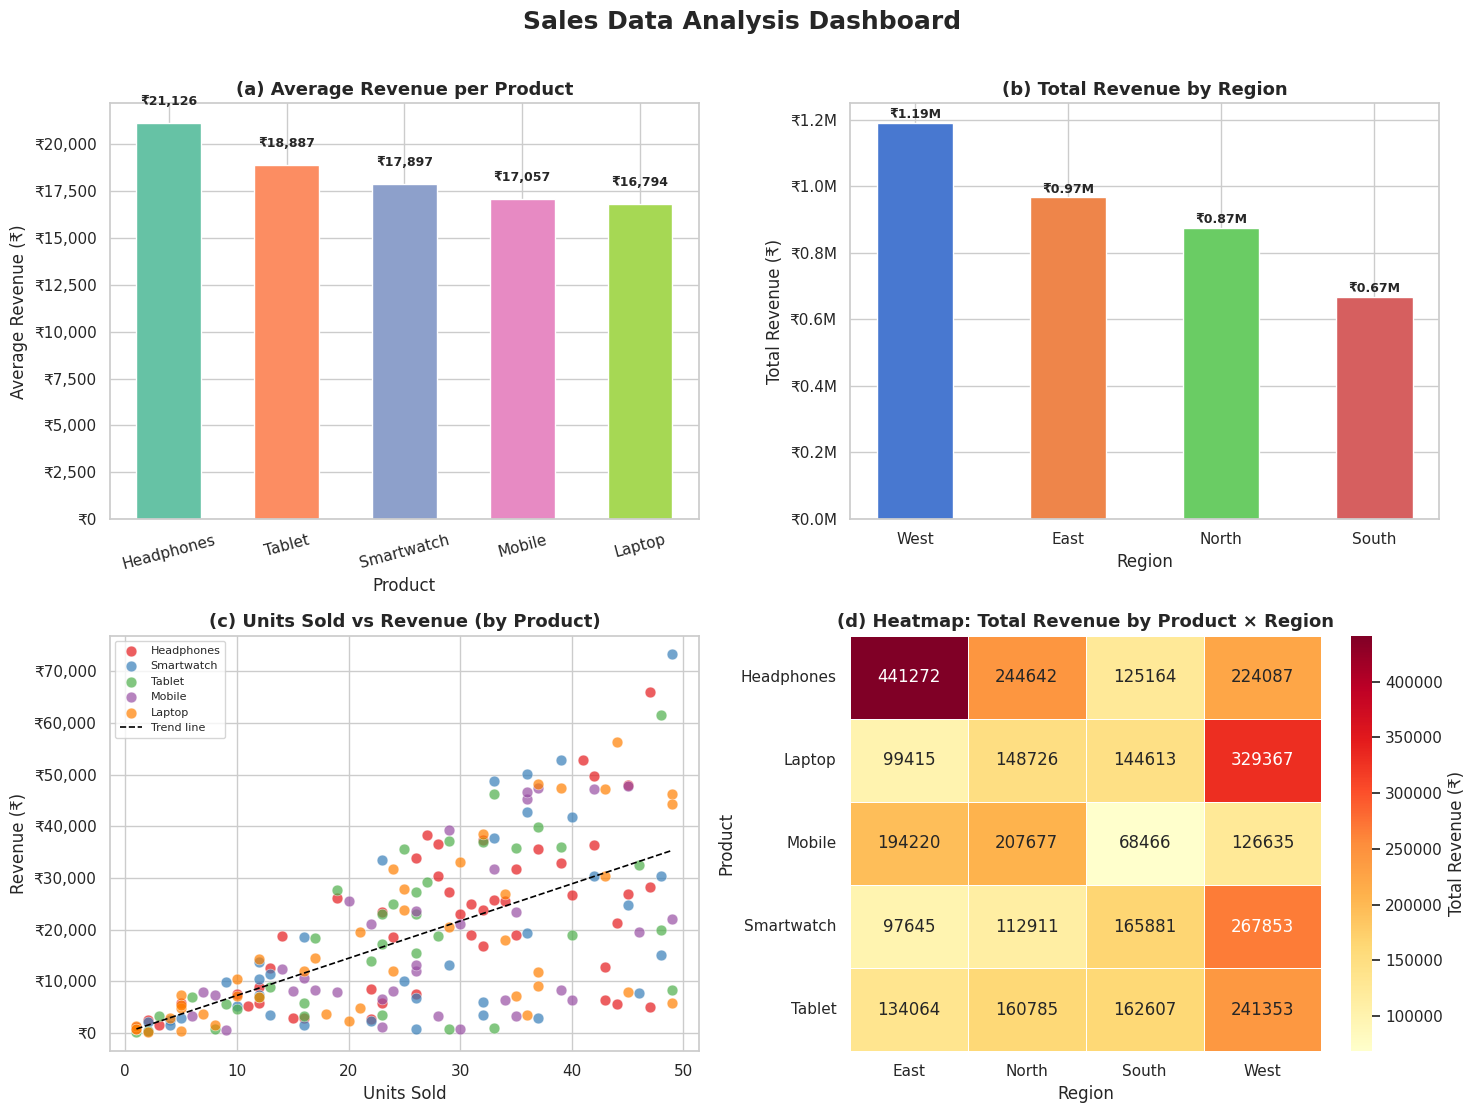

Done! Open 'analysis_dashboard.png' to view the full dashboard.


In [ ]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

df = pd.read_csv("sales_data.csv")

print("=" * 60)
print("STEP 1 — DATASET OVERVIEW")
print("=" * 60)
print(f"Shape        : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Columns      : {list(df.columns)}")
print(f"\nFirst 5 rows:")
print(df.head())

print("\n" + "=" * 60)
print("STEP 2 — BASIC STATISTICS")
print("=" * 60)

print("\n--- describe() on numeric columns ---")
print(df[["UnitsSold", "UnitPrice", "Revenue"]].describe().round(2))

avg_revenue   = df["Revenue"].mean()
avg_units     = df["UnitsSold"].mean()
avg_price     = df["UnitPrice"].mean()
total_revenue = df["Revenue"].sum()

print(f"\nAverage Revenue per Order : ₹{avg_revenue:>12,.2f}")
print(f"Average Units Sold        : {avg_units:>12.2f}")
print(f"Average Unit Price        : ₹{avg_price:>12,.2f}")
print(f"Total Revenue (all orders): ₹{total_revenue:>12,.2f}")

print("\n--- Average Revenue by Product ---")
product_avg = (
    df.groupby("Product")["Revenue"]
    .agg(["mean", "sum", "count"])
    .rename(columns={"mean": "Avg Revenue", "sum": "Total Revenue", "count": "Orders"})
    .sort_values("Avg Revenue", ascending=False)
    .round(2)
)
print(product_avg)

print("\n--- Average Revenue by Region ---")
region_avg = (
    df.groupby("Region")["Revenue"]
    .agg(["mean", "sum"])
    .rename(columns={"mean": "Avg Revenue", "sum": "Total Revenue"})
    .sort_values("Total Revenue", ascending=False)
    .round(2)
)
print(region_avg)

best_product  = product_avg["Total Revenue"].idxmax()
worst_product = product_avg["Total Revenue"].idxmin()
print(f"\nHighest-revenue product : {best_product}")
print(f"Lowest-revenue product  : {worst_product}")

corr = df[["UnitsSold", "UnitPrice", "Discount(%)", "Revenue"]].corr().round(3)
print("\n--- Correlation Matrix ---")
print(corr)

sns.set_theme(style="whitegrid", palette="Set2")
COLORS = sns.color_palette("Set2", 5)

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle("Sales Data Analysis Dashboard", fontsize=18, fontweight="bold", y=1.01)

ax1 = axes[0, 0]
products    = product_avg.index.tolist()
avg_rev_vals = product_avg["Avg Revenue"].values

bars = ax1.bar(products, avg_rev_vals, color=COLORS, edgecolor="white", width=0.55)
ax1.set_title("(a) Average Revenue per Product", fontsize=13, fontweight="bold")
ax1.set_xlabel("Product")
ax1.set_ylabel("Average Revenue (₹)")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"₹{x:,.0f}"))
ax1.tick_params(axis="x", rotation=15)

for bar, val in zip(bars, avg_rev_vals):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 800,
        f"₹{val:,.0f}",
        ha="center", va="bottom", fontsize=9, fontweight="bold"
    )

ax2 = axes[0, 1]
region_colors = sns.color_palette("muted", len(region_avg))
rbars = ax2.bar(
    region_avg.index, region_avg["Total Revenue"],
    color=region_colors, edgecolor="white", width=0.5
)
ax2.set_title("(b) Total Revenue by Region", fontsize=13, fontweight="bold")
ax2.set_xlabel("Region")
ax2.set_ylabel("Total Revenue (₹)")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"₹{x/1e6:.1f}M"))
for bar in rbars:
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5000,
        f"₹{bar.get_height()/1e6:.2f}M",
        ha="center", va="bottom", fontsize=9, fontweight="bold"
    )

ax3 = axes[1, 0]
product_list = df["Product"].unique()
palette      = dict(zip(product_list, sns.color_palette("Set1", len(product_list))))

for prod in product_list:
    subset = df[df["Product"] == prod]
    ax3.scatter(
        subset["UnitsSold"], subset["Revenue"],
        label=prod, alpha=0.7, s=60,
        color=palette[prod], edgecolors="white", linewidth=0.4
    )

m, b = np.polyfit(df["UnitsSold"], df["Revenue"], 1)
x_line = np.linspace(df["UnitsSold"].min(), df["UnitsSold"].max(), 100)
ax3.plot(x_line, m * x_line + b, "k--", linewidth=1.2, label="Trend line")

ax3.set_title("(c) Units Sold vs Revenue (by Product)", fontsize=13, fontweight="bold")
ax3.set_xlabel("Units Sold")
ax3.set_ylabel("Revenue (₹)")
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"₹{x:,.0f}"))
ax3.legend(fontsize=8, loc="upper left")

ax4 = axes[1, 1]
pivot = df.pivot_table(
    values="Revenue", index="Product", columns="Region", aggfunc="sum"
).fillna(0)

sns.heatmap(
    pivot,
    ax=ax4,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Total Revenue (₹)"},
)
ax4.set_title("(d) Heatmap: Total Revenue by Product × Region", fontsize=13, fontweight="bold")
ax4.set_xlabel("Region")
ax4.set_ylabel("Product")
ax4.tick_params(axis="x", rotation=0)
ax4.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.savefig("analysis_dashboard.png", dpi=150, bbox_inches="tight")
print("\nSaved chart: analysis_dashboard.png")


#  INSIGHTS

print("\n" + "=" * 60)
print("STEP 3 — KEY INSIGHTS & OBSERVATIONS")
print("=" * 60)

top_region = region_avg["Total Revenue"].idxmax()
low_region = region_avg["Total Revenue"].idxmin()

print(f"""
1. REVENUE LEADERS
   - '{best_product}' generates the highest total revenue among all products.
   - '{worst_product}' contributes the least — could be considered for
     discount strategies or inventory reduction.

2. REGIONAL PERFORMANCE
   - '{top_region}' leads all regions in total revenue.
   - '{low_region}' performs the weakest — targeted campaigns may help.

3. UNITS SOLD vs REVENUE (Scatter Plot insight)
   - There is a clear positive correlation between units sold and revenue
     (trend line slopes upward), meaning more units always means more income.
   - However, the spread is wide, showing that Unit Price and Discount
     also play a significant role in final revenue.

4. HEATMAP INSIGHT
   - The heatmap reveals which Product×Region combinations generate the
     most revenue — the darkest cells highlight the highest-earning combos.
   - Some cells are lighter (low revenue) and could be investigated further
     for improvement or discontinuation.

5. DISCOUNT CORRELATION
   - Correlation matrix shows Discount(%) has a slight negative correlation
     with Revenue — higher discounts don't always bring proportionally
     higher units sold to compensate.

6. AVERAGE ORDER VALUE
   - Average revenue per order is ₹{avg_revenue:,.2f}, which is a useful
     KPI for benchmarking future performance.
""")

plt.show()
print("Done! Open 'analysis_dashboard.png' to view the full dashboard.")